# Housing price trends in the Canary Islands (2007–2025)

**Dataset**: Índice de precios de vivienda según el orden de transmisión. España y comunidades autónomas. Base 2015.

**Source**: [ISTAC](https://datos.canarias.es) — Instituto Canario de Estadística

**Question**: How have housing prices in the Canary Islands evolved compared to the rest of Spain? Is the new vs second-hand gap widening?

In [1]:
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")
OUTPUT_DIR = Path("output/figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH = "data/raw/indice-de-precios-de-vivienda.csv"
df = pd.read_csv(CSV_PATH)
print(f"Rows: {len(df)} | Columns: {list(df.columns)}")
df.head(2)

Rows: 18000 | Columns: ['TERRITORIO#es', 'TERRITORIO_CODE', 'TIME_PERIOD#es', 'TIME_PERIOD_CODE', 'MEDIDAS#es', 'MEDIDAS_CODE', 'ORDEN_TRANSMISION_VIVIENDA#es', 'ORDEN_TRANSMISION_VIVIENDA_CODE', 'OBS_VALUE', 'ESTADO_OBSERVACION#es', 'ESTADO_OBSERVACION_CODE', 'CONFIDENCIALIDAD_OBSERVACION#es', 'NOTAS_OBSERVACION#es']


,TERRITORIO#es,TERRITORIO_CODE,TIME_PERIOD#es,TIME_PERIOD_CODE,MEDIDAS#es,MEDIDAS_CODE,ORDEN_TRANSMISION_VIVIENDA#es,ORDEN_TRANSMISION_VIVIENDA_CODE,OBS_VALUE,ESTADO_OBSERVACION#es,ESTADO_OBSERVACION_CODE,CONFIDENCIALIDAD_OBSERVACION#es,NOTAS_OBSERVACION#es
0,España,ES,2007 Primer trimestre,2007-Q1,Índice de precios de vivienda. Tasa de variaci...,IPV_TVP,Vivienda de segunda mano,VIVIENDA_SEGUNDA_MANO,2.0,NaN,NaN,NaN,NaN
1,España,ES,2007 Primer trimestre,2007-Q1,Índice de precios de vivienda. Tasa de variaci...,IPV_TVP,Vivienda nueva,VIVIENDA_NUEVA,2.9,NaN,NaN,NaN,NaN


In [2]:
# ── Parse and filter ────────────────────────────────────────────

# Keep only absolute index (base 2015=100), total housing type
idx = df[
    (df["MEDIDAS_CODE"] == "IPV_BASE_2015") &
    (df["ORDEN_TRANSMISION_VIVIENDA_CODE"] == "_T")
].copy()

# Parse quarter code to datetime
def parse_q(s):
    y, q = s.split("-")
    m = {"Q1": "01", "Q2": "04", "Q3": "07", "Q4": "10"}[q]
    return pd.Timestamp(f"{y}-{m}-01")

idx["date"] = idx["TIME_PERIOD_CODE"].apply(parse_q)
idx = idx.sort_values("date")

print(f"Territories: {idx['TERRITORIO#es'].nunique()}")
print(f"Date range: {idx['TIME_PERIOD_CODE'].min()} → {idx['TIME_PERIOD_CODE'].max()}")
print(f"Total rows: {len(idx)}")

Territories: 20
Date range: 2007-Q1 → 2025-Q3
Total rows: 1500


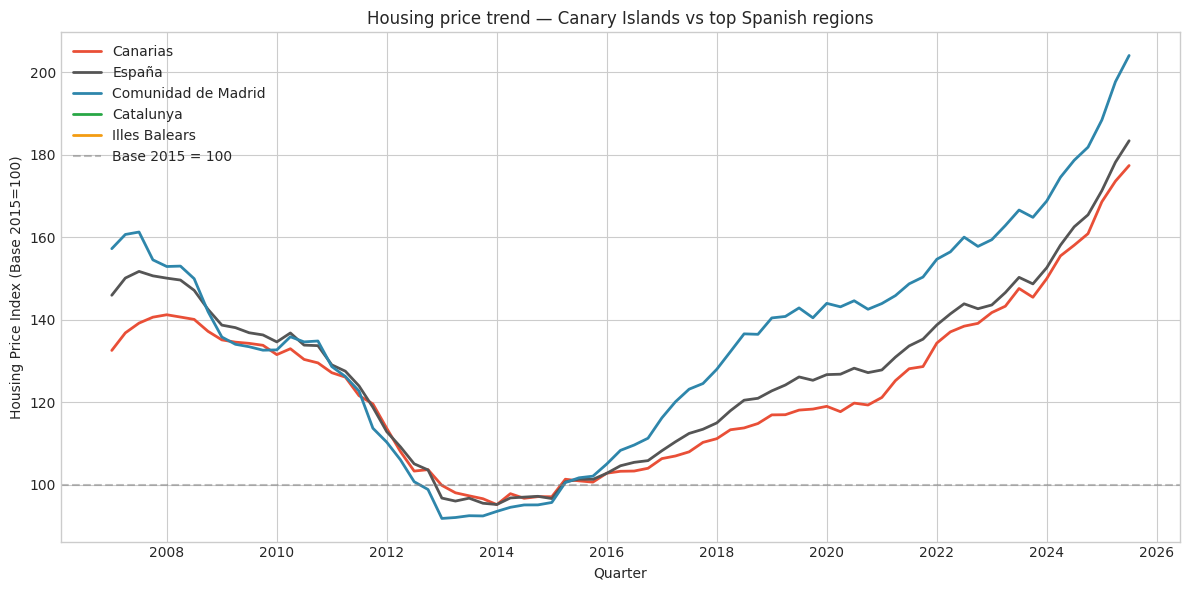

Saved: output/figures/housing_index_comparison.png


In [3]:
# ── 1. Canarias vs top Spanish regions ──────────────────────────

top_territories = ["Canarias", "España", "Comunidad de Madrid", "Catalunya", "Illes Balears"]
colors_topo = {
    "Canarias": "#E94F37",
    "España": "#555555",
    "Comunidad de Madrid": "#2E86AB",
    "Catalunya": "#28A745",
    "Illes Balears": "#F39C12",
}

fig, ax = plt.subplots(figsize=(12, 6))

for t in top_territories:
    d = idx[idx["TERRITORIO#es"] == t]
    ax.plot(d["date"], d["OBS_VALUE"], label=t, color=colors_topo[t], linewidth=2)

ax.axhline(100, color="gray", linestyle="--", alpha=0.5, label="Base 2015 = 100")
ax.set_xlabel("Quarter")
ax.set_ylabel("Housing Price Index (Base 2015=100)")
ax.set_title("Housing price trend — Canary Islands vs top Spanish regions")
ax.legend()

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "housing_index_comparison.png", dpi=150)
plt.show()
print(f"Saved: {OUTPUT_DIR / 'housing_index_comparison.png'}")

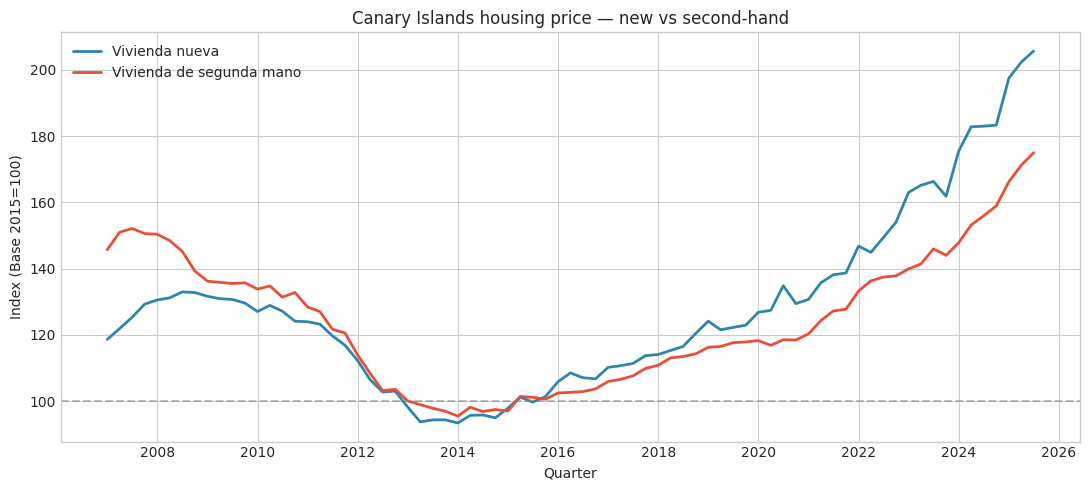

Saved: output/figures/housing_canarias_new_vs_secondhand.png


In [4]:
# ── 2. Canarias: new vs second-hand ────────────────────────────

tipi = df[
    (df["TERRITORIO#es"] == "Canarias") &
    (df["MEDIDAS_CODE"] == "IPV_BASE_2015") &
    (df["ORDEN_TRANSMISION_VIVIENDA_CODE"] != "_T")
].copy()
tipi["date"] = tipi["TIME_PERIOD_CODE"].apply(parse_q)
tipi = tipi.sort_values("date")

fig, ax = plt.subplots(figsize=(11, 5))

type_colors = {"Vivienda nueva": "#2E86AB", "Vivienda de segunda mano": "#E94F37"}
for tipo, color in type_colors.items():
    d = tipi[tipi["ORDEN_TRANSMISION_VIVIENDA#es"] == tipo]
    ax.plot(d["date"], d["OBS_VALUE"], label=tipo, color=color, linewidth=2)

ax.axhline(100, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Quarter")
ax.set_ylabel("Index (Base 2015=100)")
ax.set_title("Canary Islands housing price — new vs second-hand")
ax.legend()

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "housing_canarias_new_vs_secondhand.png", dpi=150)
plt.show()
print(f"Saved: {OUTPUT_DIR / 'housing_canarias_new_vs_secondhand.png'}")

In [5]:
# ── 3. Key numbers ──────────────────────────────────────────────

can = idx[idx["TERRITORIO#es"] == "Canarias"].sort_values("date")
spain = idx[idx["TERRITORIO#es"] == "España"].sort_values("date")

can_latest = can.iloc[-1]
spain_latest = spain.iloc[-1]
can_2007 = can.iloc[0]

print(f"Canarias Q3 2025 index: {can_latest['OBS_VALUE']:.1f} (base 2015=100)")
print(f"Canarias 2007 start:     {can_2007['OBS_VALUE']:.1f} ({can_2007['TIME_PERIOD_CODE']})")
print(f"Spain Q3 2025:           {spain_latest['OBS_VALUE']:.1f}")
print(f"Canarias vs Spain:       {can_latest['OBS_VALUE'] - spain_latest['OBS_VALUE']:+.1f} points")
print()
print("Summary table — latest quarter:")
latest = idx['TIME_PERIOD_CODE'].max()
tbl = idx[idx['TIME_PERIOD_CODE'] == latest][['TERRITORIO#es','OBS_VALUE']].set_index('TERRITORIO#es')
tbl.columns = ['Index']
tbl = tbl.sort_values('Index', ascending=False)
print(tbl.round(1))

Canarias Q3 2025 index: 177.4 (base 2015=100)
Canarias 2007 start:     132.6 (2007-Q1)
Spain Q3 2025:           183.4
Canarias vs Spain:       -6.0 points

Summary table — latest quarter:
                                Index
TERRITORIO#es                        
Ciudad Autónoma de Ceuta        204.6
Comunidad de Madrid             204.1
Ciudad Autónoma de Melilla      200.1
Illes Balears / Islas Baleares  199.6
Cataluña                        190.6
España                          183.4
Andalucía                       182.4
Cantabria                       179.3
Canarias                        177.4
Aragón                          176.6
Comunidad Valenciana            171.0
La Rioja                        168.6
País Vasco                      168.6
Región de Murcia                168.0
Comunidad Foral de Navarra      166.6
Galicia                         164.1
Principado de Asturias          162.4
Castilla y León                 162.0
Castilla - La Mancha            145.1
Extremadura   